<a href="https://colab.research.google.com/github/titoug06-commits/MYOTON2026/blob/main/In_Vitro_NoteBook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NoteBook Stéréocorrélation In Vitro (DIC)

Ce notebook reproduit l'ensemble des images analyses et des figures présentées dans la partie Stéreocorrélation du Volet In Vivroo du mémoire.

**Fichiers requis**: (disponible dans le repertoire "Données Brutes",à placer dans le même dossier que ce notebook) :
-  `DIC1-2pulses_displacement_R0.csv`
-  `disp.csv`
- `data5pts.csv`
-  `avg3pts.csv`
- `linedata.csv`

Les figures sont sauvegardées dans le dossier `/Figures`

### 1. Validation de la mesure (Impulsions MyotonPRO)

Avant d'examiner la réponse mécanique sur les empilements multicouches, une validation préalable des impulsions générées par la sonde MyotonPRO a été effectuée.

*   **Objectif :** Vérifier que la cinématique réelle correspond au paramétrage du constructeur (impulsion de 7 ms, intervalle de 0.8 s).
*   **Méthode :** Enregistrement et analyse du déplacement de la sonde (2 impulsions isolées sur un silicone arbitraire) par corrélation d'images numériques (DIC) à 1000 Hz.

Nombre d'impulsions détectées : 2

#    Début (s)    Pic (s)      Durée (ms)   Déplacement max (mm)
—————————————————————————————————————————————————————————————————
1    0.8820       0.8900       8.0          0.4393
2    1.6820       1.6900       8.0          0.4492


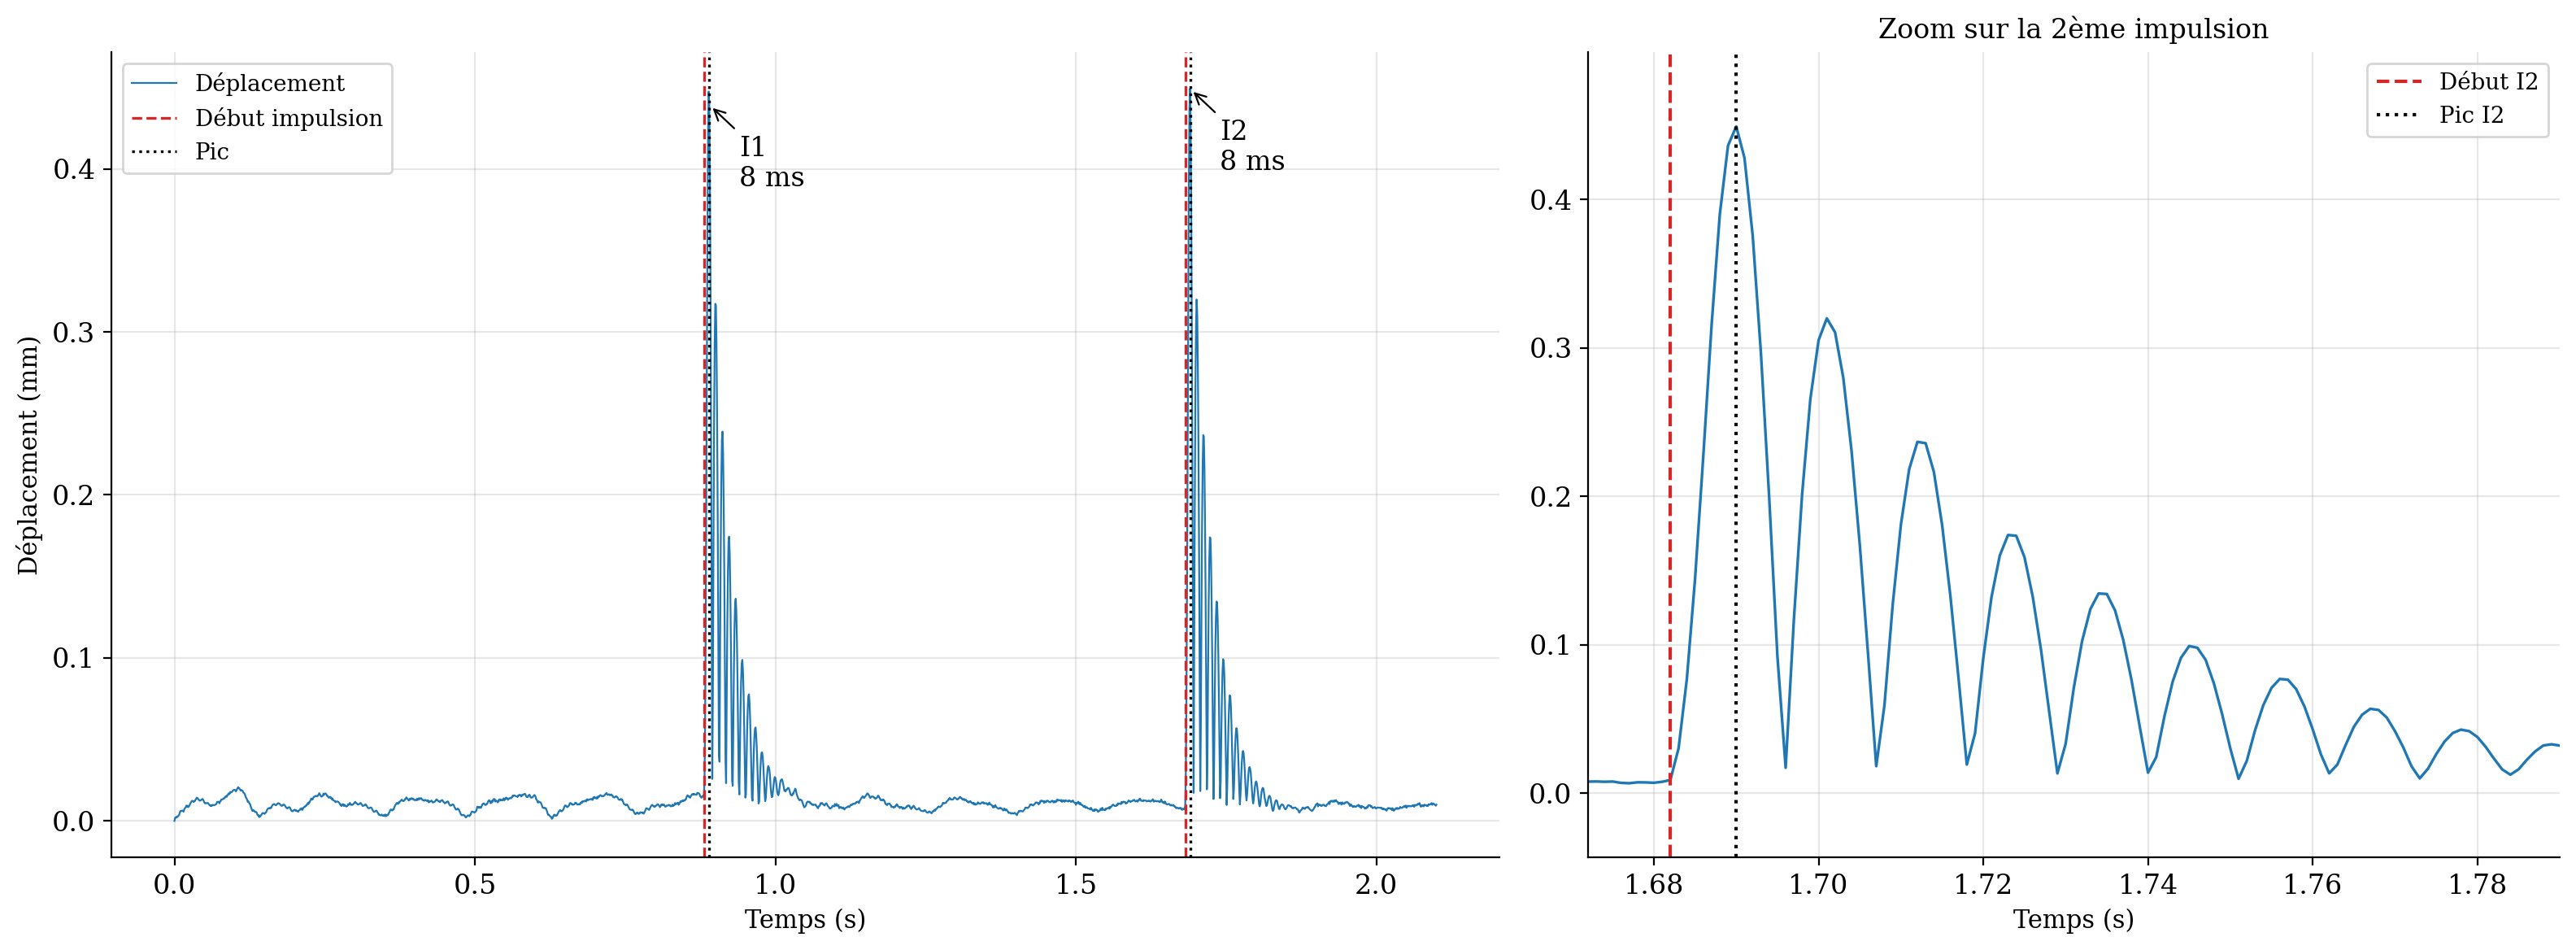

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
# Configuration des paramètres graphiques
plt.rcParams.update({'font.size': 12})

# Dossier de sortie pour les figures
os.makedirs('Figures', exist_ok=True)


# ─── 1. CHARGEMENT DES DONNÉES ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CSV_PATH = 'DIC1-2pulses_displacement_R0.csv'

temp_df = pd.read_csv(CSV_PATH, header=None)
df_columns = temp_df.iloc[1]
df = temp_df[2:].copy()
df.columns = df_columns

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

dt = 0.001 # Fréquence d'acquisition à 1000 Hz
time = df['Index [1]'].values * dt
disp = df['displacement'].values

# ─── 2. PARAMÈTRES DE DÉTECTION ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
VEL_THRESHOLD   = 5.0
MIN_PEAK_DISP   = 0.3
MIN_IMPULSE_SEP = 0.5

velocity = np.gradient(disp, dt)

# ─── 3. DÉTECTION ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
impulsion_details = []
i = 0
while i < len(time):
    # Détection du début de l'impulsion via le seuil de vitesse
    if velocity[i] > VEL_THRESHOLD and (i == 0 or velocity[i - 1] <= VEL_THRESHOLD):
        onset_idx = i - 1
        onset_time = time[i]

        search_end = min(onset_idx + 20, len(time) - 1)
        peak_idx = onset_idx + np.argmax(disp[onset_idx:search_end])

        # Affinement de la position du pic
        for j in range(onset_idx + 1, search_end):
            if velocity[j] < 0 and velocity[j - 1] >= 0:
                peak_idx = j
                break

        peak_time = time[peak_idx]
        peak_disp_mm = disp[peak_idx]
        duration_ms = (peak_time - onset_time) * 1000.0

        if peak_disp_mm >= MIN_PEAK_DISP:
            if (len(impulsion_details) == 0 or (onset_time - impulsion_details[-1]['onset_time']) > MIN_IMPULSE_SEP):
                impulsion_details.append({
                    'onset_time': onset_time,
                    'peak_time': peak_time,
                    'duration_ms': duration_ms,
                    'peak_disp': peak_disp_mm,
                })
        i = onset_idx + int(MIN_IMPULSE_SEP / dt)
    else:
        i += 1

# ─── 4. RÉSULTATS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f"Nombre d'impulsions détectées : {len(impulsion_details)}\n")
print(f"{'#':<4} {'Début (s)':<12} {'Pic (s)':<12} {'Durée (ms)':<12} {'Déplacement max (mm)'}")
print("—" * 65)
for k, d in enumerate(impulsion_details):
    print(f"{k+1:<4} {d['onset_time']:<12.4f} {d['peak_time']:<12.4f} {d['duration_ms']:<12.1f} {d['peak_disp']:.4f}")

# ─── 5. VISUALISATION ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig = plt.figure(figsize=(16, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 0.7])

# Trace complète
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(time, disp, color='tab:blue', linewidth=0.8, label='Déplacement')
for k, d in enumerate(impulsion_details):
    ax1.axvline(d['onset_time'], color='tab:red', linestyle='--', linewidth=1.2, label='Début impulsion' if k == 0 else "")
    ax1.axvline(d['peak_time'], color='black', linestyle=':', linewidth=1.2, label='Pic' if k == 0 else "")
    ax1.annotate(f"I{k+1}\n{d['duration_ms']:.0f} ms", xy=(d['peak_time'], d['peak_disp']),
                 xytext=(d['peak_time'] + 0.05, d['peak_disp'] - 0.05),
                 arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

ax1.set_xlabel('Temps (s)')
ax1.set_ylabel('Déplacement (mm)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Zoom sur la 2ème impulsion
if len(impulsion_details) >= 2:
    ax_zoom = fig.add_subplot(gs[0, 1])
    d2 = impulsion_details[1]

    z_min, z_max = d2['onset_time'] - 0.01, d2['peak_time'] + 0.1
    ax_zoom.plot(time, disp, color='tab:blue', linewidth=1.2)
    ax_zoom.axvline(d2['onset_time'], color='tab:red', linestyle='--', linewidth=1.5, label='Début I2')
    ax_zoom.axvline(d2['peak_time'], color='black', linestyle=':', linewidth=1.5, label='Pic I2')

    ax_zoom.set_xlim(z_min, z_max)
    mask = (time >= z_min) & (time <= z_max)
    if np.any(mask):
        ax_zoom.set_ylim(disp[mask].min() - 0.05, disp[mask].max() + 0.05)

    ax_zoom.set_xlabel('Temps (s)')
    ax_zoom.set_title('Zoom sur la 2ème impulsion')
    ax_zoom.grid(True, alpha=0.3)
    ax_zoom.legend()

plt.tight_layout()
plt.savefig("Figures/mesure.png", dpi=300)
plt.show()

**Conclusion de la validation :**
Les résultats expérimentaux confirment une durée mesurée de **(8 ± 1) ms** par impulsion et un intervalle inter-impulsion de **0.8 s**, cohérents avec les spécifications du constructeur. L'écart de +1 ms par rapport à la consigne de 7 ms s'inscrit directement dans l'incertitude liée à la discrétisation temporelle (1 ms par image) et à la sensibilité du seuil de détection de la vitesse de la sonde.

### 3. Analyse de l'atténuation en profondeur (Points P0 à P4)

Afin d'évaluer la propagation de la déformation mécanique générée par la sonde, les déplacements et déformations principales (E1, E2) de Lagrange sont extraits à cinq profondeurs distinctes (de la surface P0 à 28.83 mm en P4) durant la fenêtre de l'impulsion[cite: 6].

--- Atténuation en profondeur des déplacements et déformations ---
Point  Profondeur (mm) Déplacement max (mm) Déformation E1 (%) Déformation E2 (%)
   P0             0.00               0.1184               2.12               0.10
   P1             3.80               0.0841               1.01               0.02
   P2            11.11               0.1049               0.31               0.03
   P3            17.35               0.0691               0.22               0.00
   P4            28.83               0.0470               0.11               0.01
----------------------------------------------------------------------


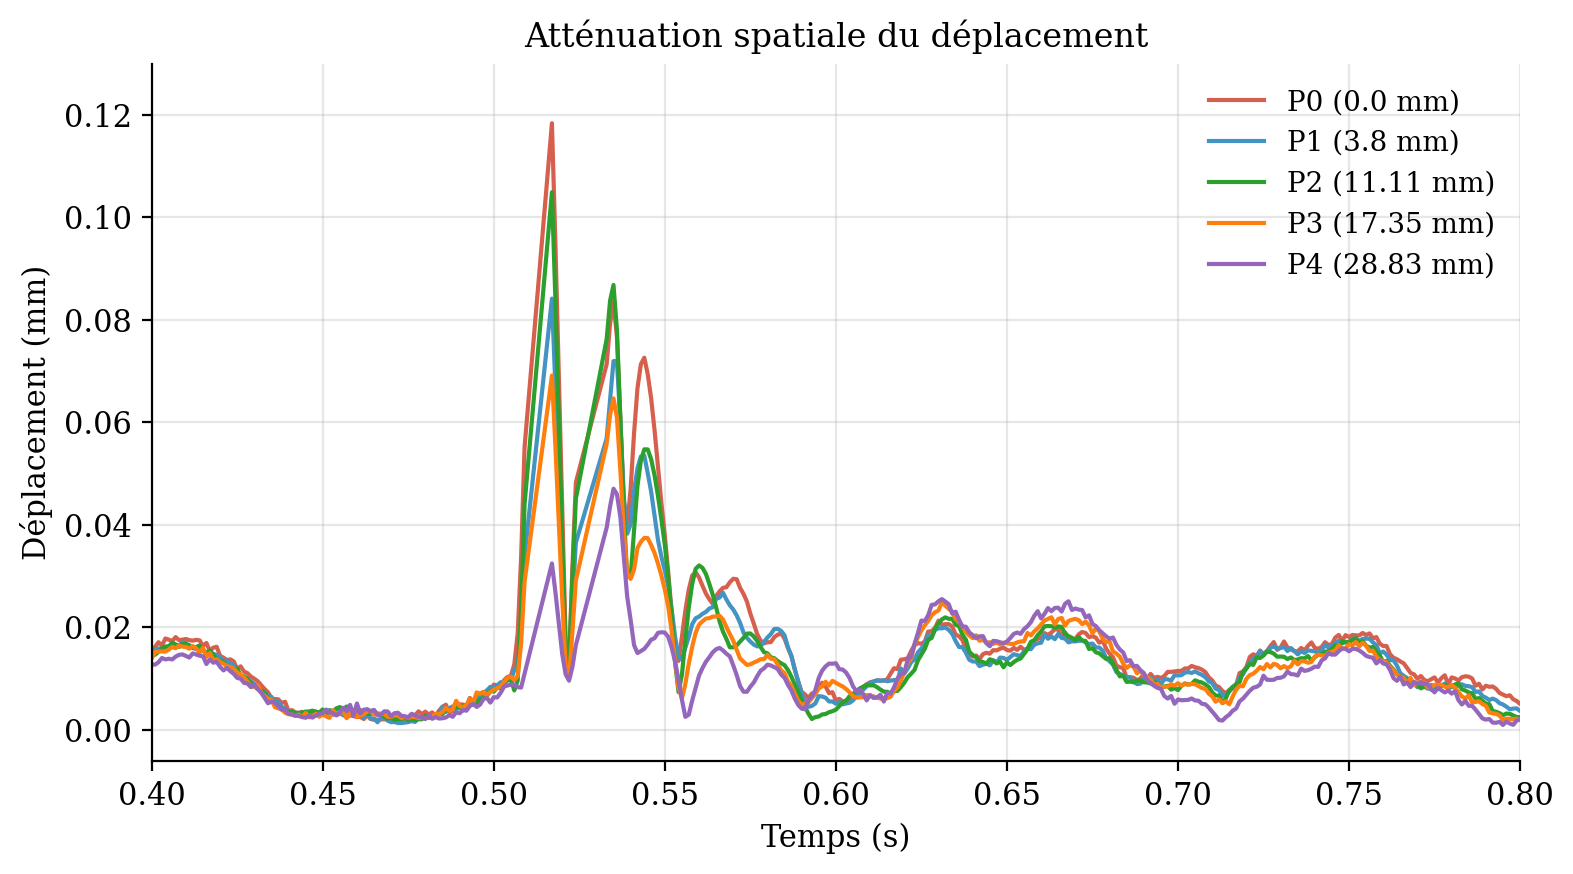

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Application du style In Vivo
plt.rcParams.update({
    'font.family':        'serif',
    'font.size':           11,
    'axes.titlesize':      12,
    'axes.labelsize':      11,
    'legend.fontsize':     10,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'figure.dpi':          200,
})

CSV_PATH_5PTS = 'data5pts.csv'

try:
    df_5pts = pd.read_csv(CSV_PATH_5PTS, header=1)
    for col in df_5pts.columns:
        df_5pts[col] = pd.to_numeric(df_5pts[col], errors='coerce')
    df_5pts.dropna(inplace=True)

    dt_5pts = 0.001
    time_5pts = df_5pts['Index [1]'].values * dt_5pts if 'Index [1]' in df_5pts.columns else np.arange(len(df_5pts)) * dt_5pts

    disp_cols = [col for col in df_5pts.columns if 'displacement' in col]
    e1_cols = [col for col in df_5pts.columns if 'e1' in col]
    e2_cols = [col for col in df_5pts.columns if 'e2' in col]

    if disp_cols and e1_cols and e2_cols:
        mask_impulse = (time_5pts >= 0.4) & (time_5pts <= 0.6)
        profondeurs = [0.00, 3.80, 11.11, 17.35, 28.83]

        # 1. Synthèse des extremums
        results = []
        for i in range(5):
            max_disp = df_5pts[disp_cols[i]].values[mask_impulse].max()
            max_e1 = df_5pts[e1_cols[i]].values[mask_impulse].max() * 100
            max_e2 = df_5pts[e2_cols[i]].values[mask_impulse].max() * 100
            results.append({
                'Point': f'P{i}',
                'Profondeur (mm)': profondeurs[i],
                'Déplacement max (mm)': f"{max_disp:.4f}",
                'Déformation E1 (%)': f"{max_e1:.2f}",
                'Déformation E2 (%)': f"{max_e2:.2f}"
            })

        df_summary = pd.DataFrame(results)
        print("--- Atténuation en profondeur des déplacements et déformations ---")
        print(df_summary.to_string(index=False))
        print("-" * 70)

        # 2. Visualisation
        fig, ax = plt.subplots(figsize=(8, 4.5))
        colors = ['#D6604D', '#4393C3', 'tab:green', 'tab:orange', 'tab:purple']

        for i, col_name in enumerate(disp_cols):
            ax.plot(time_5pts, df_5pts[col_name].values, color=colors[i % len(colors)], label=f"P{i} ({profondeurs[i]} mm)")

        ax.set_xlabel('Temps (s)')
        ax.set_xlim(0.4, 0.8)
        ax.set_ylabel('Déplacement (mm)')
        ax.set_title('Atténuation spatiale du déplacement')
        ax.grid(True, alpha=0.3)
        ax.legend(frameon=False)
        fig.tight_layout()
        plt.savefig('Figures/attenuation_profondeur.png', dpi=200)
        plt.show()

except Exception as e:
    print(f"Erreur de traitement {CSV_PATH_5PTS}: {e}")

### 4. Dynamique spatiale continue et moyenne

Analyse complémentaire illustrant le déplacement moyen sur une zone d'intérêt réduite (`avg3pts.csv`) ainsi que le profil continu le long d'un segment (`linedata.csv`) pour quantifier la déformation globale de la matrice in vitro[cite: 6].

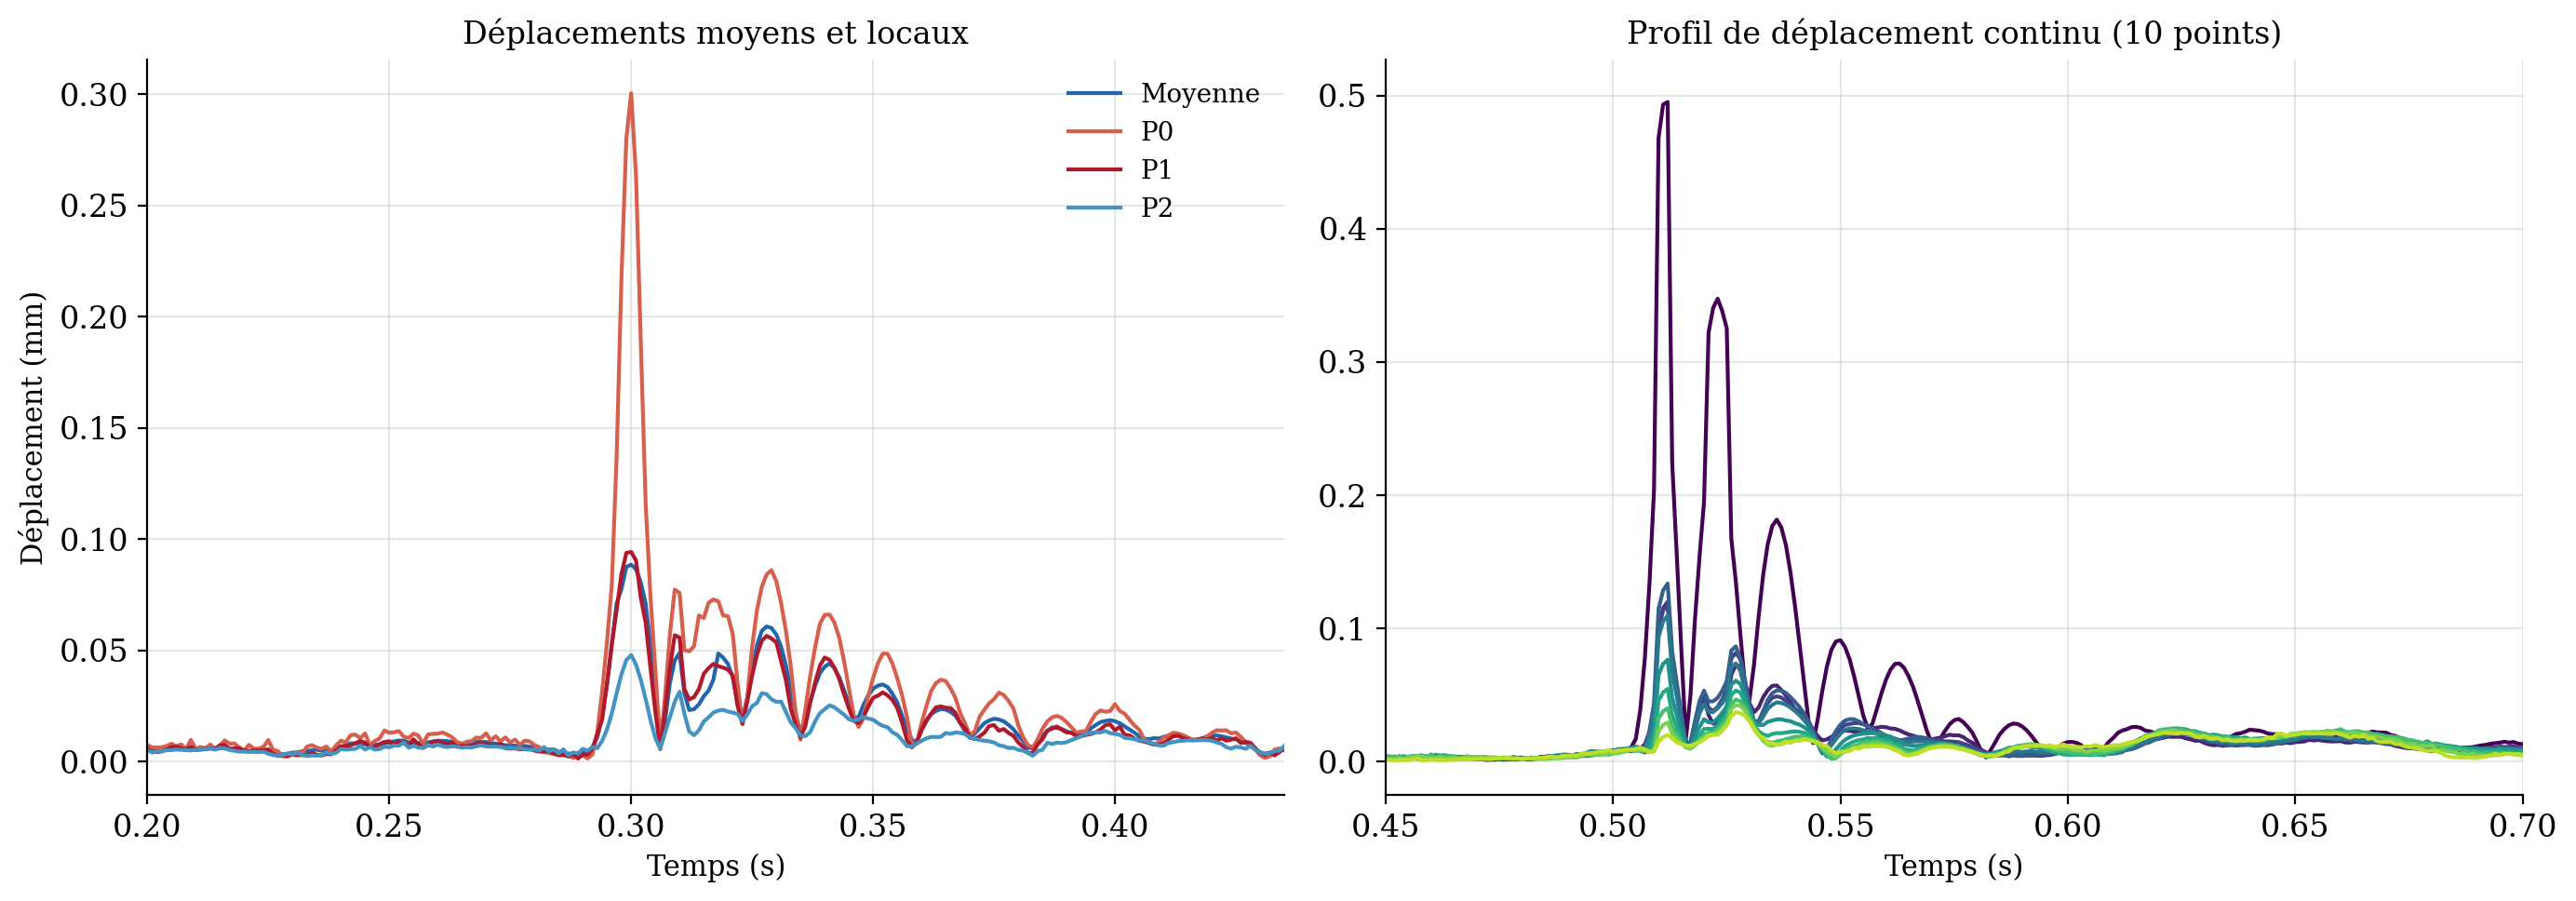

In [17]:
# ─── TRAITEMENT AVG3PTS ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CSV_PATH_AVG = 'avg3pts.csv'

temp_df_avg = pd.read_csv(CSV_PATH_AVG, header=None)
df_columns_avg = temp_df_avg.iloc[1]
df_avg = temp_df_avg[2:].copy()

# Gestion des colonnes dupliquées
cols = df_columns_avg.tolist()
new_cols = []
counts = {}
for item in cols:
    if item in counts:
        counts[item] += 1
        new_cols.append(f"{item}_{counts[item]}")
    else:
        counts[item] = 0
        new_cols.append(item)
df_avg.columns = new_cols

for col in df_avg.columns:
    df_avg[col] = pd.to_numeric(df_avg[col], errors='coerce')

dt_avg = 0.001
time_avg = df_avg['Index [1]'].values * dt_avg

disp_cols_plot = ['displacement'] if 'displacement' in df_avg.columns else []
other_cands = sorted([c for c in df_avg.columns if 'disp' in str(c).lower() and c not in ['Index [1]', 'displacement']])
disp_cols_plot.extend(other_cands[:max(0, 4 - len(disp_cols_plot))])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_avg = ['#2166AC', '#D6604D', '#B2182B', '#4393C3']

for i, col_name in enumerate(disp_cols_plot):
    label = {'displacement': 'Moyenne', 'displacement_1': 'P0',
             'displacement_2': 'P1', 'displacement_3': 'P2'}.get(col_name, col_name)
    ax1.plot(time_avg, df_avg[col_name].values, color=colors_avg[i % len(colors_avg)], lw=1.5, label=label)

ax1.set_xlabel('Temps (s)')
ax1.set_ylabel('Déplacement (mm)')
ax1.set_title('Déplacements moyens et locaux')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0.2, time_avg.max())
ax1.legend(frameon=False)


# ─── TRAITEMENT LINEDATA ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CSV_PATH_LINEDATA = 'linedata.csv'

try:
    df_linedata = pd.read_csv(CSV_PATH_LINEDATA, sep='\t')
    if df_linedata.shape[1] <= 1:
        df_linedata = pd.read_csv(CSV_PATH_LINEDATA)

    for col in df_linedata.columns:
        df_linedata[col] = pd.to_numeric(df_linedata[col], errors='coerce')
    df_linedata.dropna(inplace=True)

    time_linedata = np.arange(len(df_linedata)) * 0.001
    disp_cols_line = [col for col in df_linedata.columns if 'displacement' in col.lower()]

    if disp_cols_line:
        colors_line = plt.cm.viridis(np.linspace(0, 0.9, len(disp_cols_line)))
        for i, col_name in enumerate(disp_cols_line):
            ax2.plot(time_linedata, df_linedata[col_name].values, color=colors_line[i])

        ax2.set_xlabel('Temps (s)')
        ax2.set_xlim(0.45,0.7)
        ax2.set_title(f'Profil de déplacement continu ({len(disp_cols_line)} points)')
        ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.savefig('Figures/avg_and_linedata.png', dpi=200)
    plt.show()

except Exception as e:
    print(f"Erreur de traitement {CSV_PATH_LINEDATA}: {e}")